In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Dataset directory
DATASET_PATH = Path("../content")

# Load datasets
datasets = {
    "customers": pd.read_csv(DATASET_PATH / "olist_customers_dataset.csv"),
    "geolocation": pd.read_csv(DATASET_PATH / "olist_geolocation_dataset.csv"),
    "order_items": pd.read_csv(DATASET_PATH / "olist_order_items_dataset.csv"),
    "order_payments": pd.read_csv(DATASET_PATH / "olist_order_payments_dataset.csv"),
    "order_reviews": pd.read_csv(DATASET_PATH / "olist_order_reviews_dataset.csv"),
    "orders": pd.read_csv(DATASET_PATH / "olist_orders_dataset.csv"),
    "products": pd.read_csv(DATASET_PATH / "olist_products_dataset.csv"),
    "sellers": pd.read_csv(DATASET_PATH / "olist_sellers_dataset.csv"),
    "category_translation": pd.read_csv(DATASET_PATH / "product_category_name_translation.csv")
}

# Exploratory Data Analysis (EDA)

## 1. Overview

### 1.1 Purpose

This notebook explores the Olist E-commerce dataset from a business perspective to answer the defined business questions.

The analysis focuses on customer behavior, customer value, product performance, and seller performance. The findings from this notebook will support the Business Requirements, Data Requirements, Analytics Engineering, and Executive Dashboard development in the subsequent phases.

### 1.2 Analysis Scope

This exploratory analysis focuses on four key business areas:

- Customer Segmentation
- Customer Value by State
- Product Category Performance
- Seller Performance

Each analysis is conducted based on the corresponding business question and is intended to identify business insights before designing the Data Warehouse and Business Metric Layer.

# 2. Business Question 1

## 2.1 Business Question

### Business Question

**Which customer segments should be prioritized for marketing and customer engagement strategies based on purchasing behavior?**

### Objective

Identify customer segments based on purchasing behavior to support targeted marketing and customer engagement strategies.

---

## 2.2 Required Information

To answer this business question, the dataset should provide the following information:

| Required Information | Purpose |
|----------------------|---------|
| Customer Identifier | Identify unique customers |
| Purchase Date | Calculate customer recency |
| Order Identifier | Calculate purchase frequency |
| Product Price | Calculate customer spending |
| Payment Amount | Validate customer transaction value |

---

## 2.3 Data Availability Check

### Purpose

Verify whether the dataset contains sufficient information to support customer segmentation based on purchasing behavior.


In [ ]:
required_columns = {
    "customers": [
        "customer_id",
        "customer_unique_id"
    ],
    "orders": [
        "order_id",
        "customer_id",
        "order_purchase_timestamp"
    ],
    "order_items": [
        "order_id",
        "price"
    ],
    "order_payments": [
        "order_id",
        "payment_value"
    ]
}

for table, columns in required_columns.items():
    print(f"\n{table}")
    print("-" * 40)

    available = datasets[table].columns

    for column in columns:
        print(
            f"{column:<30}"
            f"{'yes' if column in available else 'no'}"
        )


customers
----------------------------------------
customer_id                   yes
customer_unique_id            yes

orders
----------------------------------------
order_id                      yes
customer_id                   yes
order_purchase_timestamp      yes

order_items
----------------------------------------
order_id                      yes
price                         yes

order_payments
----------------------------------------
order_id                      yes
payment_value                 yes


**Findings**
- Customer identifiers are available through both `customer_id` and `customer_unique_id`.
- Order timestamps are available for calculating customer recency.
- Product prices and payment values are available for measuring customer spending.
- The dataset contains all essential attributes required for customer segmentation.

## 2.4 Exploratory Analysis

### Purpose

Explore the distribution of customer purchasing behavior before constructing customer segments.

### Analysis 1 – Purchase Frequency

Analyze the distribution of purchase frequency to understand how often customers place orders.

In [ ]:
monthly_orders = (
    datasets['customers']
    .merge(datasets['orders'],on="customer_id")
)

monthly_orders["month"] = (
    pd.to_datetime(
        monthly_orders["order_purchase_timestamp"]
    )
    .dt.to_period("M")
)

monthly_orders = (
    monthly_orders
    .groupby(
        [
            "customer_unique_id",
            "month"
        ]
    )["order_id"]
    .nunique()
    .reset_index()
)

In [ ]:
monthly_orders.groupby("month")["order_id"].mean()

,order_id
month,
2016-09,1.000000
2016-10,1.009346
2016-12,1.000000
2017-01,1.045752
2017-02,1.014245
2017-03,1.015140
2017-04,1.013491
2017-05,1.020690
2017-06,1.020440


### Analysis 2 – Purchase Value

Analyze the distribution of customer spending to identify purchasing value patterns.

In [ ]:
revenue = (
    datasets["order_items"]
    .groupby("order_id")["price"]
    .sum()
)

revenue

,price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90
...,...
fffc94f6ce00a00581880bf54a75a037,299.99
fffcd46ef2263f404302a634eb57f7eb,350.00
fffce4705a9662cd70adb13d4a31832d,99.90


In [ ]:
revenue.describe()

,price
count,98666.000000
mean,137.754076
std,210.645145
min,0.850000
25%,45.900000
50%,86.900000
75%,149.900000
max,13440.000000


### Analysis 3 – Purchase Recency

Analyze customer recency to understand how recently customers have made purchases.

In [ ]:
datasets['orders'].order_purchase_timestamp = pd.to_datetime(
    datasets['orders'].order_purchase_timestamp
)

snapshot_date = datasets['orders'].order_purchase_timestamp.max()

recency = (
    snapshot_date
    - datasets['orders'].order_purchase_timestamp
).dt.days

recency

,order_purchase_timestamp
0,380
1,84
2,70
3,332
4,245
...,...
99436,587
99437,253
99438,416
99439,281


In [ ]:
recency.describe()

,order_purchase_timestamp
count,99441.000000
mean,289.900192
std,153.667316
min,0.000000
25%,166.000000
50%,271.000000
75%,400.000000
max,772.000000


### Analysis 4 — Payment Method Distribution
Analyze customer payment methods to understand payment preferences and identify the usage of vouchers in purchasing behavior.

In [ ]:
customer_payment = (
    datasets['customers']
    .merge(datasets['orders'], on="customer_id")
    .merge(datasets['order_payments'], on="order_id")
)

payment_distribution = (
    customer_payment["payment_type"]
    .value_counts()
)

payment_distribution

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [ ]:
payment_distribution.plot(
    kind="bar",
    figsize=(8,5),
    title="Payment Method Distribution"
)

### Analysis 5 — Voucher Usage Rate
Analyze the percentage of voucher customer use

In [ ]:
voucher_rate = (
    customer_payment["payment_type"]
    .eq("voucher")
    .value_counts(normalize=True)
    .mul(100)
)

voucher_rate

,proportion
payment_type,
False,94.441022
True,5.558978


**Findings**
- Customer purchasing activity varies over time, indicating differences in purchasing frequency among customers.
- Customer spending is unevenly distributed, suggesting that different customer groups contribute differently to business value.
- Multiple payment methods are available, including vouchers, providing additional behavioral attributes for customer segmentation.
- The dataset provides sufficient information to construct customer behavioral metrics such as Frequency, Monetary Value, Recency, and Payment Preference.

# 3. Business Question 2

## 3.1 Business Question

### Business Question

**Which customer segments generate the highest business value in each state and should be prioritized for customer retention strategies?**

### Objective

Identify high-value customer segments across different states to optimize customer retention strategies..

---

## 3.2 Required Information

To answer this business question, the dataset should provide the following information:

| Required Information | Purpose |
|----------------------|---------|
| Customer Identifier | Identify unique customers |
| Customer State | Analyze customer segments by state |
| Purchase Date | Calculate customer recency |
| Order Identifier | Calculate purchase frequency |
| Product Price | Calculate customer spending |
| Payment Amount | Validate customer transaction value |

---

## 3.3 Data Availability Check

### Purpose

Verify whether the dataset contains sufficient information to support customer segmentation based on purchasing behavior.


In [ ]:
required_columns = {
    "customers": [
        "customer_id",
        "customer_unique_id",
        "customer_state"
    ],
    "orders": [
        "order_id",
        "customer_id",
        "order_purchase_timestamp"
    ],
    "order_items": [
        "order_id",
        "price"
    ]
}

for table, columns in required_columns.items():
    print(f"\n{table}")
    print("-" * 40)

    available = datasets[table].columns

    for column in columns:
        print(
            f"{column:<35}"
            f"{'yes' if column in available else 'no'}"
        )


customers
----------------------------------------
customer_id                        yes
customer_unique_id                 yes
customer_state                     yes

orders
----------------------------------------
order_id                           yes
customer_id                        yes
order_purchase_timestamp           yes

order_items
----------------------------------------
order_id                           yes
price                              yes


## 3.4 Exploratory Analysis

### Purpose

Explore the business value which earned by customer segments across different states.



### Analysis 1 — Customer Distribution by State

Analyze the distribution of customers across different states.

In [ ]:
customer_state = (
    datasets["customers"].customer_state
    .value_counts()
    .sort_values(ascending=False)
)

customer_state

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


<Axes: title={'center': 'Customer Distribution by State'}, xlabel='customer_state'>

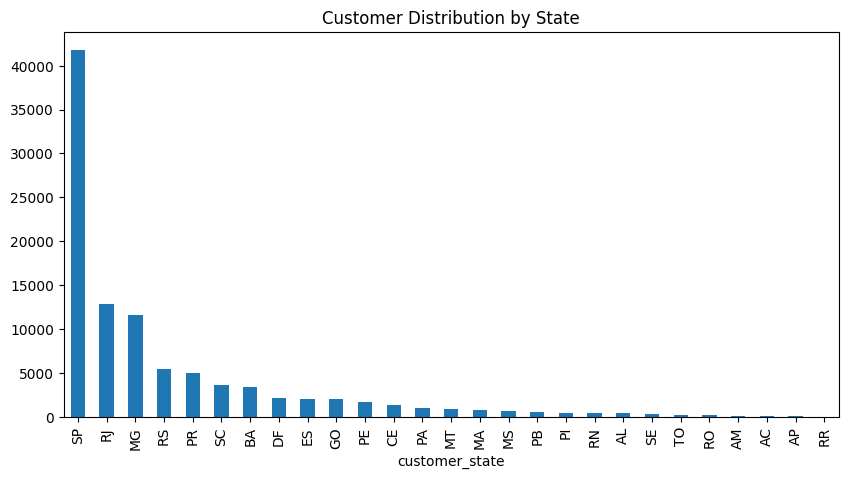

In [ ]:
customer_state.plot(
    kind="bar",
    figsize=(10,5),
    title="Customer Distribution by State"
)

### Analysis 2 — Revenue Distribution by State

Analyze the business revenue of each state

In [ ]:
customer_orders = (
    datasets['customers']
    .merge(datasets['orders'], on="customer_id")
    .merge(datasets['order_payments'], on="order_id")
)

customer_revenue = (
    customer_payment
    .groupby(
        [
            "customer_state",
            "customer_unique_id"
        ]
    )
    .agg(
        total_revenue=("payment_value", "sum")
    )
    .reset_index()
)

customer_revenue.head()

,customer_state,customer_unique_id,total_revenue
0,AC,005ee3e015ec18092d7782e507cf68fe,187.96
1,AC,057e56752630652c673205286270e5a3,240.53
2,AC,05cf4ddb31059a169df61046881d812f,298.30
3,AC,0845d810b482f4d469d3c88380f4a7d5,595.49
4,AC,086d6b5b5ba195a91aa0a6ec8e75d1a4,995.18


<Axes: >

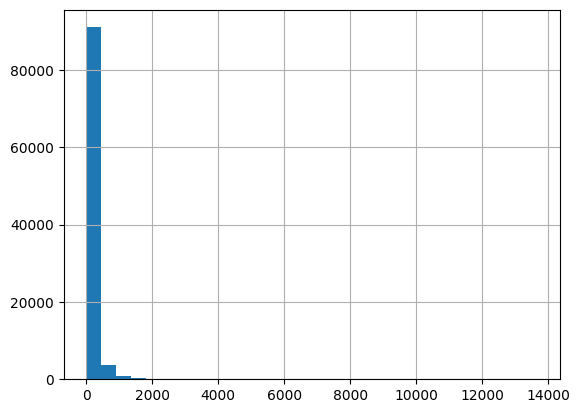

In [ ]:
customer_revenue["total_revenue"].hist(
    bins=30
)

### Analysis 3 — Customer Purchase Frequency by State

Analyze customer purchase frequency in different state

In [ ]:
customer_purchase = (
    datasets["customers"]
    .merge(datasets['orders'], on="customer_id")
)

customer_purchase["purchase_month"] = (
    pd.to_datetime(customer_purchase["order_purchase_timestamp"])
    .dt.to_period("M")
)

monthly_purchase = (
    customer_purchase
    .groupby(
        [
            "customer_state",
            "customer_unique_id",
            "purchase_month"
        ]
    )
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_purchase.head()

,customer_state,customer_unique_id,purchase_month,total_orders
0,AC,005ee3e015ec18092d7782e507cf68fe,2017-10,1
1,AC,057e56752630652c673205286270e5a3,2018-06,1
2,AC,05cf4ddb31059a169df61046881d812f,2017-11,1
3,AC,0845d810b482f4d469d3c88380f4a7d5,2018-05,1
4,AC,086d6b5b5ba195a91aa0a6ec8e75d1a4,2017-05,1


In [ ]:
monthly_orders = (
    monthly_purchase
    .groupby("purchase_month")["total_orders"]
    .sum()
)

monthly_orders

,total_orders
purchase_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


<Axes: title={'center': 'Monthly Purchase Frequency'}, xlabel='purchase_month'>

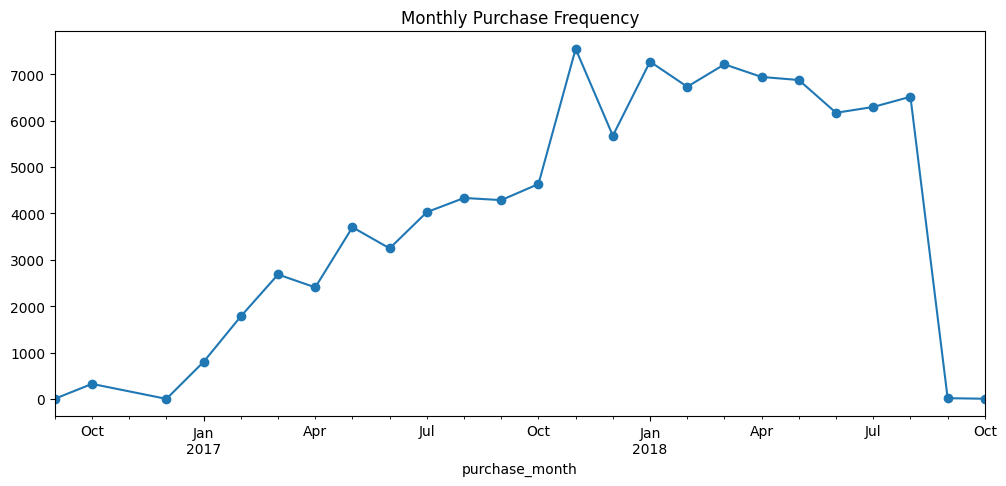

In [ ]:
monthly_orders.plot(
    kind="line",
    figsize=(12,5),
    marker="o",
    title="Monthly Purchase Frequency"
)

### Analysis 4 — Customer Revenue Distribution

Analyze the customer revenue distribution in distinct states

In [ ]:
customer_revenue = (
    customer_orders
    .groupby(["customer_state", "customer_unique_id"])["price"]
    .sum()
    .reset_index(name="revenue")
)

customer_revenue.head()

,customer_state,customer_unique_id,revenue
0,AC,005ee3e015ec18092d7782e507cf68fe,159.99
1,AC,057e56752630652c673205286270e5a3,179.00
2,AC,05cf4ddb31059a169df61046881d812f,189.94
3,AC,0845d810b482f4d469d3c88380f4a7d5,524.90
4,AC,086d6b5b5ba195a91aa0a6ec8e75d1a4,961.60


<Axes: >

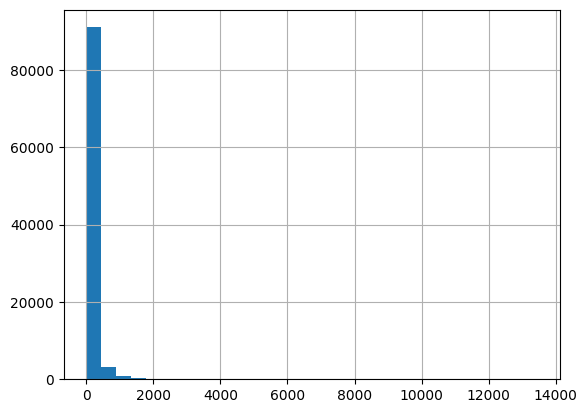

In [ ]:
customer_revenue["revenue"].hist(
    bins=30
)

### Analysis 5 — Purchase Recency by State

Analyze each state's purchase recency

In [ ]:
customer_orders["order_purchase_timestamp"] = pd.to_datetime(
    customer_orders["order_purchase_timestamp"]
)

snapshot_date = customer_orders["order_purchase_timestamp"].max()

customer_recency = (
    customer_orders
    .groupby(["customer_state", "customer_unique_id"])["order_purchase_timestamp"]
    .max()
    .reset_index()
)

customer_recency["recency"] = (
    snapshot_date
    - customer_recency["order_purchase_timestamp"]
).dt.days

customer_recency.head()

,customer_state,customer_unique_id,order_purchase_timestamp,recency
0,AC,005ee3e015ec18092d7782e507cf68fe,2017-10-01 09:57:51,336
1,AC,057e56752630652c673205286270e5a3,2018-06-16 15:30:56,78
2,AC,05cf4ddb31059a169df61046881d812f,2017-11-14 16:05:37,292
3,AC,0845d810b482f4d469d3c88380f4a7d5,2018-05-03 22:54:21,122
4,AC,086d6b5b5ba195a91aa0a6ec8e75d1a4,2017-05-14 19:52:34,476


<Axes: >

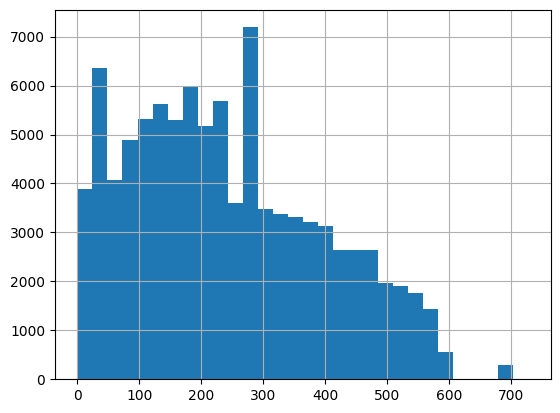

In [ ]:
customer_recency["recency"].hist(
    bins=30
)

**Findings**
- Customer distribution varies considerably across states.
- Customer business value differs among customers within each state.
- Purchasing activity changes over time, providing a foundation for customer retention analysis.
- The dataset supports state-level customer value analysis and future customer segmentation.

# 4. Business Question 3

## 4.1 Business Question

### Business Question

**Which product categories contribute the most to sales performance in each state and should be prioritized in business strategies?**

### Objective

Identify the product categories that contribute the most to sales performance across different states to support product and sales optimization.

---

## 4.2 Required Information

To answer this business question, the dataset should provide the following information:

| Required Information | Purpose |
|----------------------|---------|
| Customer Identifier | Identify unique customers |
| Customer State | Analyze customer segments by state |
| Purchase Date | Calculate customer recency |
| Order Identifier | Calculate purchase frequency |
| Product Price | Calculate customer spending |
| Payment Amount | Validate customer transaction value |
| Product Identifier | Identify unique product |
| Product translation | Understand what the product is |

---

## 4.3 Data Availability Check

### Purpose

Verify whether the dataset contains sufficient information to support customer segmentation based on purchasing behavior.


In [ ]:
required_columns = {
    "customers": [
        "customer_id",
        "customer_state"
    ],
    "orders": [
        "order_id",
        "customer_id"
    ],
    "order_items": [
        "order_id",
        "product_id",
        "price"
    ],
    "products": [
        "product_id",
        "product_category_name"
    ],
    "category_translation": [
        "product_category_name",
        "product_category_name_english"
    ]
}

for table, columns in required_columns.items():
    print(f"\n{table}")
    print("-" * 40)

    available = datasets[table].columns

    for column in columns:
        print(
            f"{column:<40}"
            f"{'yes' if column in available else 'no'}"
        )


customers
----------------------------------------
customer_id                             yes
customer_state                          yes

orders
----------------------------------------
order_id                                yes
customer_id                             yes

order_items
----------------------------------------
order_id                                yes
product_id                              yes
price                                   yes

products
----------------------------------------
product_id                              yes
product_category_name                   yes

category_translation
----------------------------------------
product_category_name                   yes
product_category_name_english           yes


## 4.4 Exploratory Analysis

### Purpose

Explore each product's purchase frequency and business value in different states



### Analysis 1 — Product Category Distribution

Analyze the distribution of products

In [ ]:
product_category = (
    datasets['products'].product_category_name
    .value_counts()
)

product_category

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


<Axes: title={'center': 'Top 20 Product Categories'}, xlabel='product_category_name'>

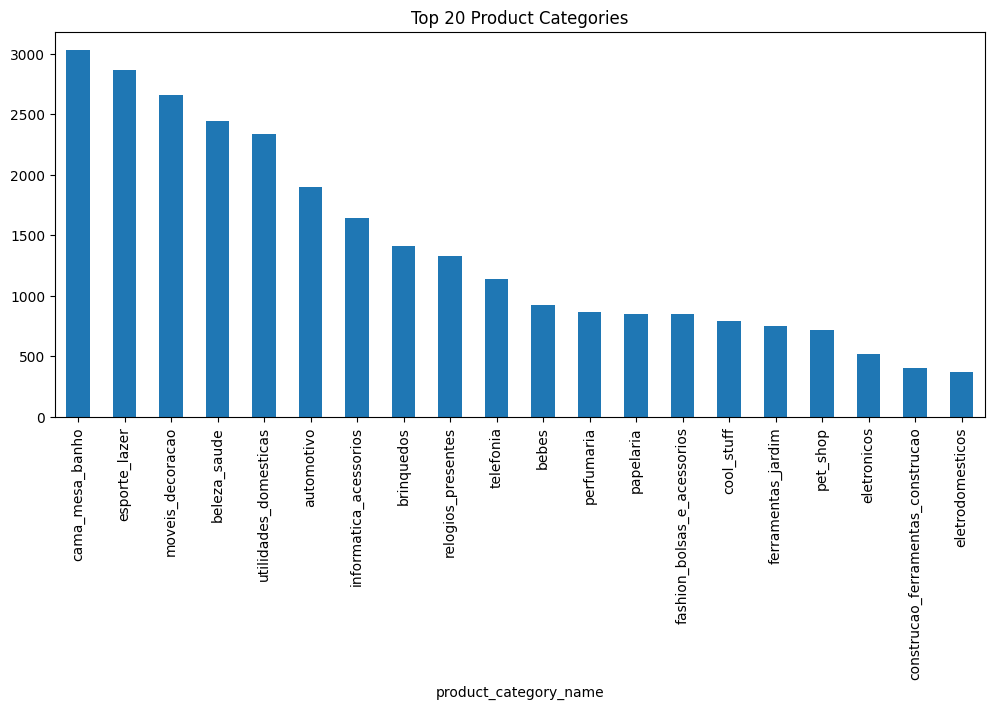

In [ ]:
product_category.head(20).plot(
    kind="bar",
    figsize=(12,5),
    title="Top 20 Product Categories"
)

### Analysis 2 — Product Sales Distribution

Analyze distinct product's sale

In [ ]:
product_sales = (
    datasets['order_items']
    .groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

,price
product_id,
bb50f2e236e5eea0100680137654686c,63885.00
6cdd53843498f92890544667809f1595,54730.20
d6160fb7873f184099d9bc95e30376af,48899.34
d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
99a4788cb24856965c36a24e339b6058,43025.56
...,...
2e8316b31db34314f393806fd7b6e185,2.99
680cc8535be7cc69544238c1d6a83fe8,2.90
8a3254bee785a526d548a81a9bc3c9be,2.55


<Axes: >

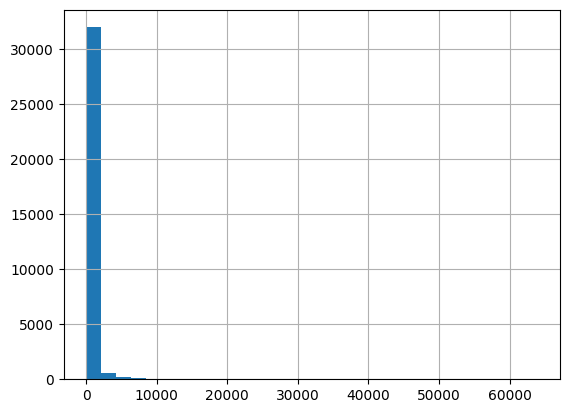

In [ ]:
product_sales.hist(
    bins=30
)

### Analysis 3 — Product Category Distribution by State

Analyze the distribution of different product category in each states

In [ ]:
category_state = (
    datasets['customers']
    .merge(datasets['orders'], on="customer_id")
    .merge(datasets['order_items'], on="order_id")
    .merge(datasets['products'], on="product_id")
    .groupby(
        [
            "customer_state",
            "product_category_name"
        ]
    )
    .size()
    .reset_index(name="total_orders")
)

category_state.head()

,customer_state,product_category_name,total_orders
0,AC,artigos_de_natal,1
1,AC,automotivo,4
2,AC,bebes,3
3,AC,beleza_saude,7
4,AC,brinquedos,3


<Axes: title={'center': 'Top Product Categories by Number of Orders'}, xlabel='product_category_name'>

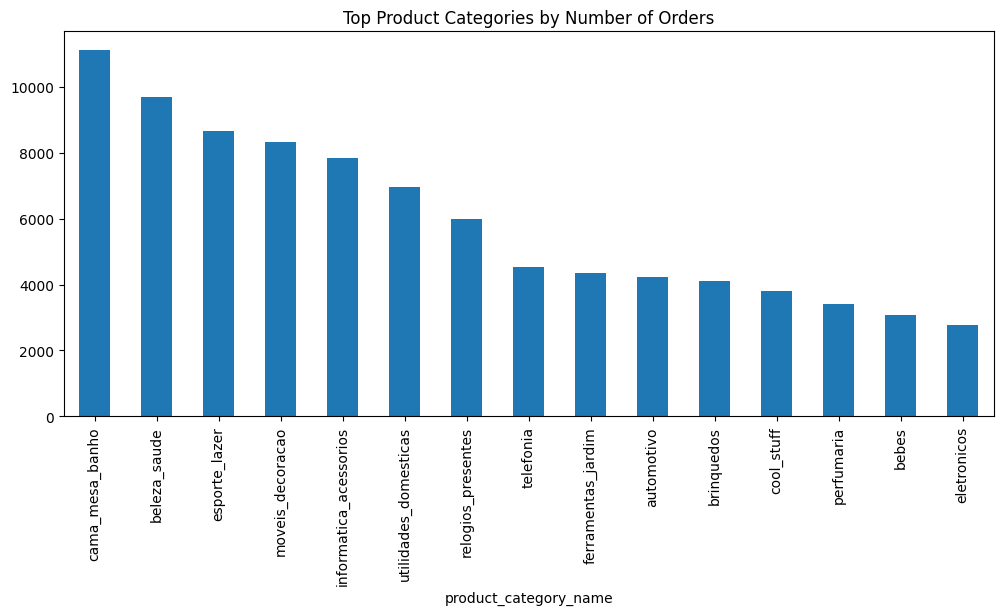

In [ ]:
top_categories = (
    category_state
    .groupby("product_category_name")["total_orders"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_categories.plot(
    kind="bar",
    figsize=(12,5),
    title="Top Product Categories by Number of Orders"
)

### Analysis 4 — Revenue by Product Category

Analyze each product category's revenue

In [ ]:
category_revenue = (
    datasets['customers']
    .merge(datasets['orders'], on="customer_id")
    .merge(datasets['order_items'], on="order_id")
    .merge(datasets['products'], on="product_id")
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,price
product_category_name,
beleza_saude,1258681.34
relogios_presentes,1205005.68
cama_mesa_banho,1036988.68
esporte_lazer,988048.97
informatica_acessorios,911954.32
...,...
flores,1110.04
casa_conforto_2,760.27
cds_dvds_musicais,730.00


<Axes: title={'center': 'Top Product Categories by Revenue'}, xlabel='product_category_name'>

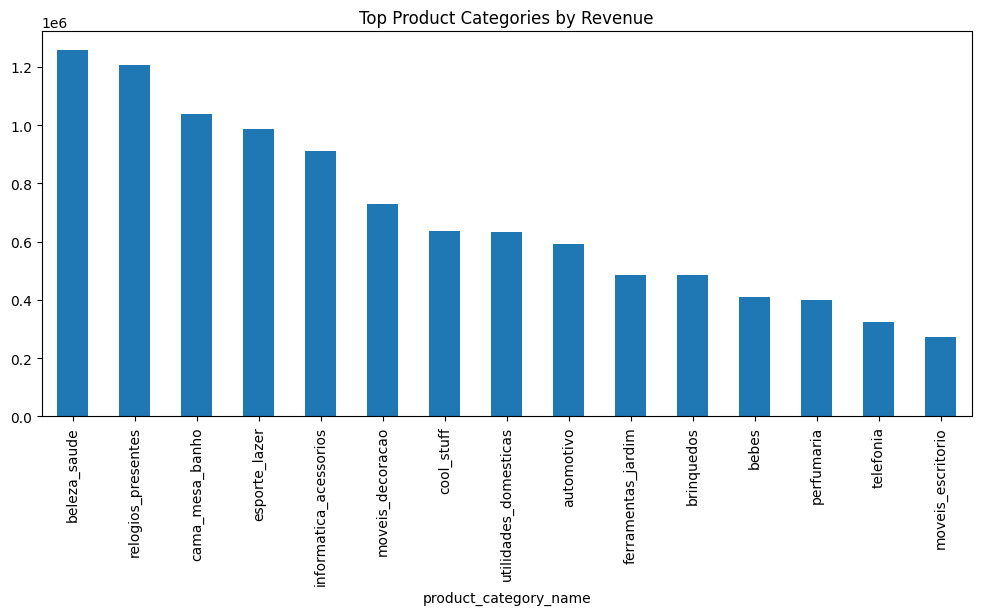

In [ ]:
category_revenue.head(15).plot(
    kind="bar",
    figsize=(12,5),
    title="Top Product Categories by Revenue"
)

**Findings**
- Product categories are unevenly distributed across the dataset.
- Sales performance varies significantly among different product categories.
- Product purchasing patterns differ across states.
- The dataset provides sufficient information to identify high-performing product categories by state.

# 5. Business Question 4

## 5.1 Business Question

### Business Question

**Which sellers should be prioritized for performance improvement in each state to enhance customer experience and business performance?**

### Objective

Identify underperforming sellers based on business and customer experience metrics.

---

## 5.2 Required Information

To answer this business question, the dataset should provide the following information:

| Required Information | Purpose |
|----------------------|---------|
| Customer Identifier | Identify unique customers |
| Customer State | Analyze customer segments by state |
| Purchase Date | Calculate customer recency |
| Order Identifier | Calculate purchase frequency |
| Review Score | Evaluate customer's satisfication |
| Payment Amount | Validate customer transaction value |
| Seller identifier | Identify unique seller |

---

## 5.3 Data Availability Check

### Purpose

Verify whether the dataset contains sufficient information to support customer segmentation based on purchasing behavior.


In [ ]:
required_columns = {
    "customers": [
        "customer_id",
        "customer_state"
    ],
    "orders": [
        "order_id",
        "customer_id"
    ],
    "order_items": [
        "order_id",
        "seller_id",
        "price",
        "freight_value"
    ],
    "order_reviews": [
        "order_id",
        "review_score"
    ],
    "sellers": [
        "seller_id"
    ]
}

for table, columns in required_columns.items():
    print(f"\n{table}")
    print("-" * 40)

    available = datasets[table].columns

    for column in columns:
        print(
            f"{column:<35}"
            f"{'yes' if column in available else 'no'}"
        )


customers
----------------------------------------
customer_id                        yes
customer_state                     yes

orders
----------------------------------------
order_id                           yes
customer_id                        yes

order_items
----------------------------------------
order_id                           yes
seller_id                          yes
price                              yes
freight_value                      yes

order_reviews
----------------------------------------
order_id                           yes
review_score                       yes

sellers
----------------------------------------
seller_id                          yes


## 5.4 Exploratory Analysis

### Purpose

Explore the distribution of seller int different states



### Analysis 1 — Seller Distribution

Analyze the number of sellers

In [ ]:
seller_state = (
    datasets['sellers'].seller_state
    .value_counts()
    .sort_values(ascending=False)
)

seller_state

,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


<Axes: title={'center': 'Seller Distribution by State'}, xlabel='seller_state'>

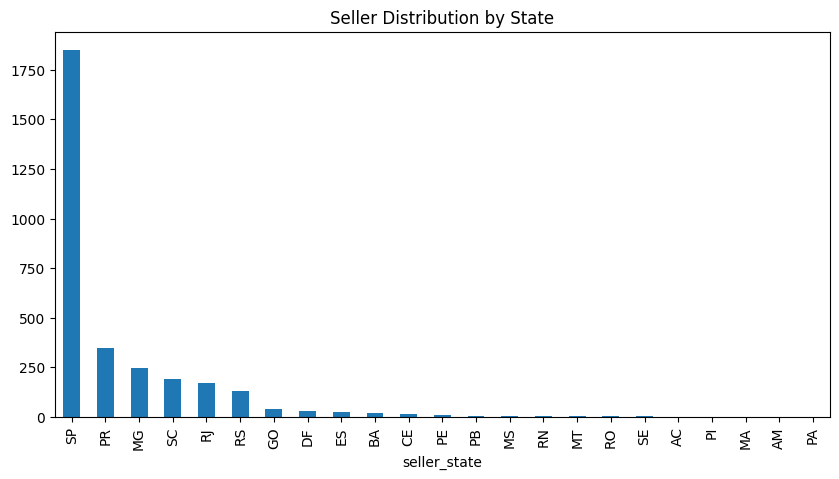

In [ ]:
seller_state.plot(
    kind="bar",
    figsize=(10,5),
    title="Seller Distribution by State"
)

### Analysis 2 — Seller Revenue Distribution

Analyze the revenue distribution of each seller

In [ ]:
seller_revenue = (
    datasets['order_items']
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

seller_revenue.head()

,price
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
53243585a1d6dc2643021fd1853d8905,222776.05
4a3ca9315b744ce9f8e9374361493884,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,194042.03
7c67e1448b00f6e969d365cea6b010ab,187923.89


<Axes: >

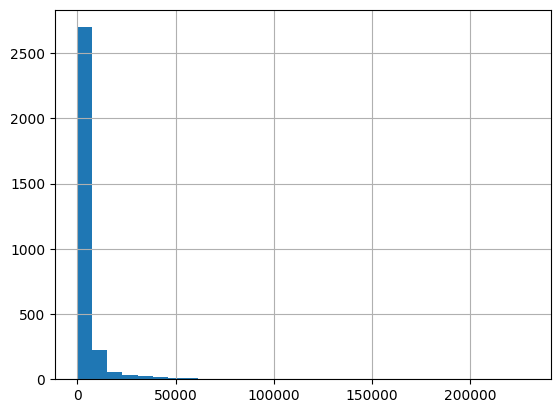

In [ ]:
seller_revenue.hist(
    bins=30
)

### Analysis 3 — Seller Order Volume

Analyze the order volume of each seller

In [ ]:
seller_orders = (
    datasets['order_items']
    .groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

seller_orders.head()

,order_id
seller_id,
6560211a19b47992c3666cc44a7e94c0,1854
4a3ca9315b744ce9f8e9374361493884,1806
cc419e0650a3c5ba77189a1882b7556a,1706
1f50f920176fa81dab994f9023523100,1404
da8622b14eb17ae2831f4ac5b9dab84a,1314


<Axes: >

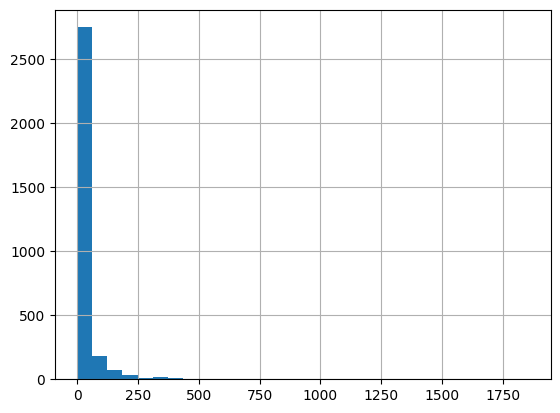

In [ ]:
seller_orders.hist(
    bins=30
)

### Analysis 4 — Seller Review Score Distribution

Analyze the review score of each seller

In [ ]:
seller_reviews = (
    datasets['order_items']
    .merge(datasets['order_reviews'], on="order_id")
    .groupby("seller_id")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

seller_reviews.head()

,review_score
seller_id,
feb793c88d836c3a75efa4b5a3465d70,5.0
e59e575a175fadcadf8479e191770425,5.0
e595809a6c31ec4314fd06ef198c244d,5.0
e560e4022d8f7aebf155db95946c5c0f,5.0
e5545d4d4473876ea78c5bcebca365c3,5.0


<Axes: >

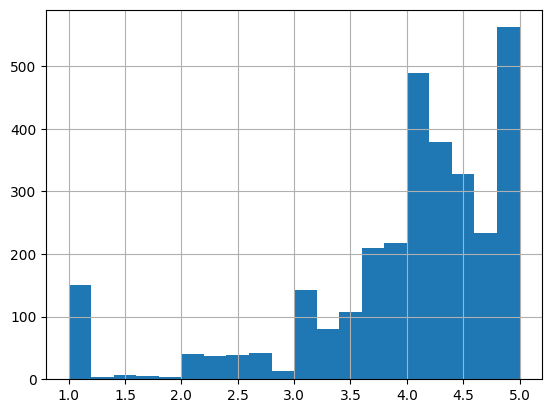

In [ ]:
seller_reviews.hist(
    bins=20
)

### Analysis 5 — Seller Performance by State

Analyze seller performance of each state

In [ ]:
seller_state = (
    datasets['customers']
    .merge(datasets['orders'], on="customer_id")
    .merge(datasets['order_items'], on="order_id")
    .groupby(
        [
            "customer_state",
            "seller_id"
        ]
    )
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)

seller_state.head()

,customer_state,seller_id,total_orders,total_revenue
0,AC,04308b1ee57b6625f47df1d56f00eedf,1,527.90
1,AC,048c2757535328e0d7dac690ad3c0aae,1,220.70
2,AC,06a2c3af7b3aee5d69171b0e14f0ee87,1,66.99
3,AC,0be8ff43f22e456b4e0371b2245e4d01,1,47.90
4,AC,0ebd97a106433a45a4aebe57c1799778,1,89.90


In [ ]:
seller_state.describe()

,total_orders,total_revenue
count,17567.000000,17567.000000
mean,5.693061,773.703176
std,21.113386,2633.471434
min,1.000000,3.500000
25%,1.000000,89.700000
50%,2.000000,209.000000
75%,4.000000,578.885000
max,814.000000,88238.160000


**Findings**
- Sellers are distributed unevenly across different states.
- Seller revenue and order volume vary considerably.
- Customer review scores provide an additional perspective on seller performance.
- The dataset supports the construction of seller performance metrics by combining business performance and customer experience indicators.